In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('c:/data/test/customer_cluster.csv')
df.head()

,age,income,spending_score
0,58,3955,16
1,48,3585,82
2,34,5943,81
3,27,5073,21
4,40,3021,43


In [2]:
df.columns

Index(['age', 'income', 'spending_score'], dtype='object')

In [3]:
X = df[['age', 'income', 'spending_score']]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,age,income,spending_score,cluster
0,58,3955,16,0
1,48,3585,82,1
2,34,5943,81,2
3,27,5073,21,0
4,40,3021,43,1


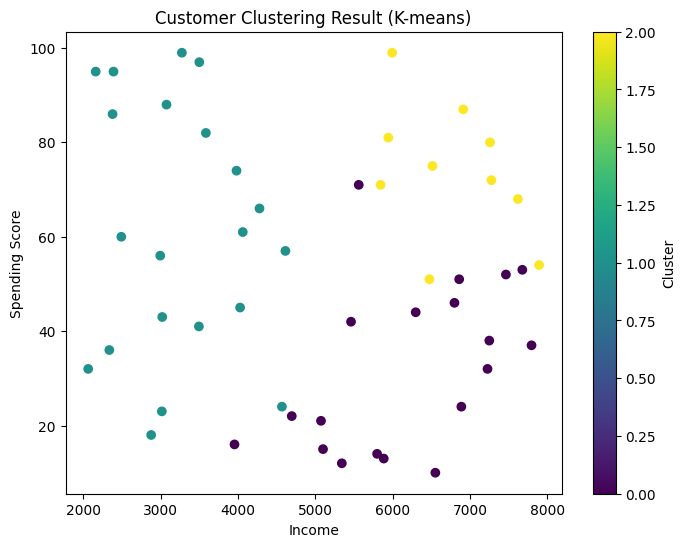

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    df['income'],
    df['spending_score'],
    c=df['cluster'],
    cmap='viridis'
)
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Customer Clustering Result (K-means)')
plt.colorbar(label='Cluster')
plt.show()

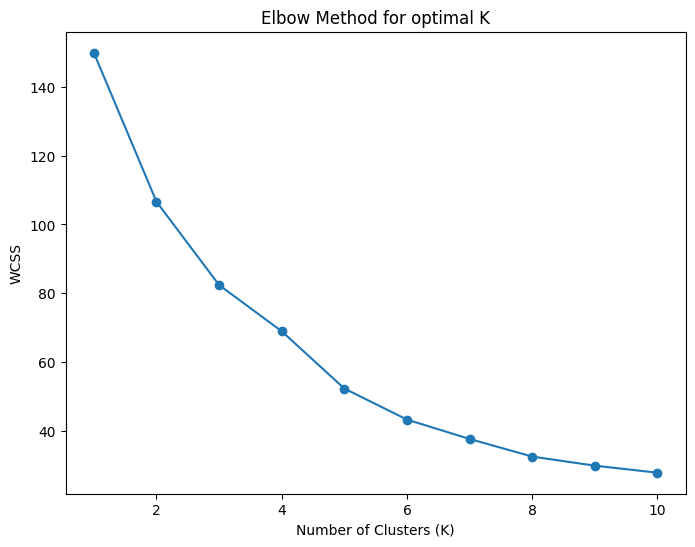

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# Within-Cluster Sum of Squares
# 각 데이터가 자기 클라스터의 중심과 얼마나 떨어져 있는지를 모두 더한 값
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for optimal K')
plt.show()